# 🧬 Hybrid GA–PSO NAS — Phase 4: PSO Hyperparameter Optimizer

**Input from Phase 3:** Best architecture chromosome `[fitness=0.9932]`  
**Goal:** Find optimal `[learning_rate, dropout, batch_size]` for that architecture using PSO  
**PSO:** Built from scratch in pure NumPy — no external library  

---
### What this notebook covers:
1. Rebuild environment + all prior phase files
2. Write `pso/pso_optimizer.py` — full PSO engine (pure NumPy)
3. Write `pso/pso_fitness.py` — fitness function (proxy train with given hyperparams)
4. Write `pso/pso_utils.py` — swarm visualisation & convergence tools
5. Run PSO on the best architecture from Phase 3
6. Plot swarm convergence + particle trajectories
7. Compare PSO-tuned vs default hyperparameters
8. Save PSO results + best hyperparams to disk

---
## STEP 1: Reinstall & Rebuild Everything from Phase 1–3

In [1]:
!pip install deap pymoo xgboost scikit-learn --quiet
print('Packages ready')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 46.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 328.3/328.3 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 kB 51.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 7.9 MB/s eta 0:00:00
Packages ready


In [2]:
import os, sys, json, time, copy, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from mpl_toolkits.mplot3d import Axes3D
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED   = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

print(f' Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'   GPU    : {torch.cuda.get_device_name(0)}')

 Device : cuda
   GPU    : Tesla T4


In [3]:
# ── Rebuild project folders ────────────────────────────────────────────
PROJECT_ROOT = '/content/nas_project'
DATA_DIR     = f'{PROJECT_ROOT}/data'

DIRS = [
    'config','search_space','ga','pso','surrogate',
    'training','evaluation','utils',
    'results','results/models','results/logs','results/plots','experiments','data'
]
for d in DIRS:
    os.makedirs(f'{PROJECT_ROOT}/{d}', exist_ok=True)
    if not any(x in d for x in ['results','data','experiments']):
        open(f'{PROJECT_ROOT}/{d}/__init__.py','w').close()
open(f'{PROJECT_ROOT}/__init__.py','w').close()
sys.path.insert(0, PROJECT_ROOT)
print(' Project folders ready')

 Project folders ready


In [4]:
# ── Rebuild chromosome.py (Phase 2) ──────────────────────────────────
CHROMOSOME_CODE = r'''
import torch, torch.nn as nn
import numpy as np

FILTERS     = [16, 32, 64, 128, 256, 512]
KERNELS     = [3, 5, 7]
DENSE_UNITS = [64, 128, 256, 512, 1024]
ACTIVATIONS = ["relu", "elu", "leaky_relu", "selu"]
POOL_TYPES  = ["max", "avg", "none"]

def _get_act(name):
    return {"relu": nn.ReLU(), "elu": nn.ELU(),
            "leaky_relu": nn.LeakyReLU(0.1), "selu": nn.SELU()}[name]

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel, pool_type, use_bn, act_name, use_skip):
        super().__init__()
        pad = kernel // 2
        self.use_skip = use_skip and (in_ch == out_ch)
        self.conv = nn.Conv2d(in_ch, out_ch, kernel, padding=pad, bias=not use_bn)
        self.bn   = nn.BatchNorm2d(out_ch) if use_bn else nn.Identity()
        self.act  = _get_act(act_name)
        self.pool = (nn.MaxPool2d(2,2) if pool_type=="max" else
                     nn.AvgPool2d(2,2) if pool_type=="avg" else nn.Identity())
    def forward(self, x):
        identity = x
        out = self.act(self.bn(self.conv(x)))
        if self.use_skip: out = out + identity
        return self.pool(out)

class NASModel(nn.Module):
    def __init__(self, chromosome, in_channels=1, image_size=28, num_classes=10):
        super().__init__()
        self.chromosome = list(chromosome)
        c = chromosome
        num_conv  = max(1, min(4, int(c[0])))
        filt_idxs = [max(0, min(5, int(c[i]))) for i in range(1,5)]
        kernel    = KERNELS[max(0, min(2, int(c[5])))]
        pool_type = POOL_TYPES[max(0, min(2, int(c[6])))]
        num_dense = max(1, min(3, int(c[7])))
        dense_idx = max(0, min(4, int(c[8])))
        act_name  = ACTIVATIONS[max(0, min(3, int(c[9])))]
        use_bn    = bool(int(c[10]))
        use_skip  = bool(int(c[11]))
        filters   = [FILTERS[i] for i in filt_idxs[:num_conv]]
        dense_u   = DENSE_UNITS[dense_idx]
        conv_layers = []
        in_ch = in_channels
        for out_ch in filters:
            conv_layers.append(ConvBlock(in_ch, out_ch, kernel, pool_type, use_bn, act_name, use_skip))
            in_ch = out_ch
        self.features   = nn.Sequential(*conv_layers)
        self.gap        = nn.AdaptiveAvgPool2d(1)
        dense_layers    = []
        in_f = in_ch
        for _ in range(num_dense):
            dense_layers += [nn.Linear(in_f, dense_u), _get_act(act_name), nn.Dropout(0.3)]
            in_f = dense_u
        dense_layers.append(nn.Linear(in_f, num_classes))
        self.classifier = nn.Sequential(*dense_layers)
    def forward(self, x):
        x = self.features(x)
        x = self.gap(x).flatten(1)
        return self.classifier(x)
    def get_info(self):
        n = sum(p.numel() for p in self.parameters() if p.requires_grad)
        return {"num_params": n, "chromosome": self.chromosome}

def decode_chromosome(chromosome, in_channels=1, image_size=28, num_classes=10):
    return NASModel(chromosome, in_channels, image_size, num_classes)

def chromosome_to_features(chromosome):
    c = chromosome
    num_conv  = max(1, min(4, int(c[0])))
    filt_idxs = [max(0, min(5, int(c[i]))) for i in range(1,5)]
    feats = [
        num_conv,
        FILTERS[filt_idxs[0]], FILTERS[filt_idxs[1]],
        FILTERS[filt_idxs[2]], FILTERS[filt_idxs[3]],
        KERNELS[max(0, min(2, int(c[5])))],
        max(0, min(2, int(c[6]))),
        max(1, min(3, int(c[7]))),
        DENSE_UNITS[max(0, min(4, int(c[8])))],
        max(0, min(3, int(c[9]))),
        int(c[10]), int(c[11]),
        sum(FILTERS[filt_idxs[i]] for i in range(num_conv)),
    ]
    return np.array(feats, dtype=np.float32)
'''
with open(f'{PROJECT_ROOT}/search_space/chromosome.py','w') as f:
    f.write(CHROMOSOME_CODE)

from search_space.chromosome import decode_chromosome, chromosome_to_features
m = decode_chromosome([2,1,3,0,0,0,0,2,2,0,1,0])
assert m(torch.randn(2,1,28,28)).shape == (2,10)
print('chromosome.py ready')

chromosome.py ready


In [5]:
# ── Rebuild proxy_trainer.py (Phase 3) ────────────────────────────────
PROXY_CODE = '''
import time
import torch
import torch.nn as nn
import torch.optim as optim

def proxy_train(model, train_loader, val_loader, device,
                epochs=3, lr=1e-3, dropout_rate=0.3,
                weight_decay=1e-4, verbose=False):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()
    num_params   = sum(p.numel() for p in model.parameters() if p.requires_grad)
    train_losses = []
    val_accs     = []
    t0           = time.time()
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()
        scheduler.step()
        train_losses.append(epoch_loss / len(train_loader))
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                correct += (model(xb).argmax(1) == yb).sum().item()
                total   += yb.size(0)
        val_accs.append(correct / total)
        if verbose:
            print(f"  Epoch {epoch+1}/{epochs} loss={train_losses[-1]:.4f} val={val_accs[-1]:.4f}")
    return {
        "val_accuracy" : val_accs[-1],
        "best_val_acc" : max(val_accs),
        "num_params"   : num_params,
        "train_time"   : time.time() - t0,
        "train_losses" : train_losses,
        "val_accs"     : val_accs,
    }
'''
with open(f'{PROJECT_ROOT}/training/proxy_trainer.py','w') as f:
    f.write(PROXY_CODE)
print('proxy_trainer.py ready')

proxy_trainer.py ready


In [6]:
# ── DataLoader helper ─────────────────────────────────────────────────
def get_dataloaders(dataset_name='MNIST', data_dir=DATA_DIR,
                    batch_size=64, val_split=0.1):
    if dataset_name == 'MNIST':
        t = transforms.Compose([transforms.ToTensor(),
                                 transforms.Normalize((0.1307,),(0.3081,))])
        train_full = datasets.MNIST(data_dir, train=True,  download=True, transform=t)
        test_ds    = datasets.MNIST(data_dir, train=False, download=True, transform=t)
    else:
        t = transforms.Compose([transforms.ToTensor(),
                                 transforms.Normalize((0.4914,0.4822,0.4465),
                                                      (0.2023,0.1994,0.2010))])
        train_full = datasets.CIFAR10(data_dir, train=True,  download=True, transform=t)
        test_ds    = datasets.CIFAR10(data_dir, train=False, download=True, transform=t)
    val_size   = int(len(train_full) * val_split)
    train_size = len(train_full) - val_size
    train_ds, val_ds = random_split(train_full, [train_size, val_size],
                                     generator=torch.Generator().manual_seed(42))
    kw = dict(num_workers=2, pin_memory=True)
    return (DataLoader(train_ds, batch_size, shuffle=True,  **kw),
            DataLoader(val_ds,   batch_size, shuffle=False, **kw),
            DataLoader(test_ds,  batch_size, shuffle=False, **kw))

print('Loading MNIST...')
train_loader, val_loader, test_loader = get_dataloaders(batch_size=64)
print(f'MNIST ready — {len(train_loader)} train batches, {len(val_loader)} val batches')

Loading MNIST...


100%|██████████| 9.91M/9.91M [00:00<00:00, 16.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 507kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.58MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.35MB/s]

MNIST ready — 844 train batches, 94 val batches


---
## STEP 2: Define the Best Architecture from Phase 3
Phase 3 found val_acc = 0.9932. We load that chromosome and PSO will tune its hyperparameters.

In [7]:
# ── Best chromosome from Phase 3 ──────────────────────────────────────
# If you have ga_history.json from Drive, load it — otherwise use the
# hardcoded best chromosome recorded in the Phase 3 output.

GA_HISTORY_PATH = f'{PROJECT_ROOT}/results/logs/ga_history.json'

if os.path.isfile(GA_HISTORY_PATH):
    with open(GA_HISTORY_PATH) as f:
        ga_data = json.load(f)
    best_ind = max(ga_data['individuals'], key=lambda x: x['fitness'])
    BEST_CHROMOSOME = best_ind['chromosome']
    BEST_GA_ACC     = best_ind['fitness']
    print(f'Loaded best chromosome from ga_history.json')
else:
    # Fallback: hardcode the best chromosome from Phase 3
    # Replace this with your actual best chromosome if different
    BEST_CHROMOSOME = [2, 1, 3, 0, 0, 0, 0, 2, 2, 0, 1, 0]
    BEST_GA_ACC     = 0.9932
    print(' ga_history.json not found — using fallback chromosome')
    print('   To use your actual best: copy ga_history.json from Drive to:')
    print(f'   {GA_HISTORY_PATH}')

print(f'\n  Best chromosome  : {BEST_CHROMOSOME}')
print(f'  GA val accuracy  : {BEST_GA_ACC:.4f} ({BEST_GA_ACC*100:.2f}%)')

# Verify it decodes correctly
test_model = decode_chromosome(BEST_CHROMOSOME)
info       = test_model.get_info()
print(f'  Parameters       : {info["num_params"]:,}')

 ga_history.json not found — using fallback chromosome
   To use your actual best: copy ga_history.json from Drive to:
   /content/nas_project/results/logs/ga_history.json

  Best chromosome  : [2, 1, 3, 0, 0, 0, 0, 2, 2, 0, 1, 0]
  GA val accuracy  : 0.9932 (99.32%)
  Parameters       : 138,858


---
## STEP 3: Write `pso/pso_optimizer.py`
Pure NumPy PSO. Each particle is a 3D vector `[log10(lr), dropout, log2(batch_size)]`. The swarm converges toward the hyperparameter combination that maximises val accuracy.

In [8]:
PSO_OPTIMIZER_CODE = r'''
"""
pso/pso_optimizer.py
Particle Swarm Optimization — pure NumPy implementation.
"""
import numpy as np
import json, os, time

BOUNDS = np.array([
    [-5.0, -1.0],   # log10(lr)
    [ 0.0,  0.6],   # dropout
    [ 4.0,  7.0],   # log2(batch_size)
])

DIM_NAMES = ["log10_lr", "dropout", "log2_batch"]

def decode_particle(position):
    log_lr, dropout, log2_bs = position
    return {
        "lr"         : float(10 ** log_lr),
        "dropout"    : float(np.clip(dropout, 0.0, 0.6)),
        "batch_size" : int(2 ** round(log2_bs)),
    }

class Particle:
    def __init__(self, bounds, rng):
        # Explicitly use the number of dimensions from bounds
        n_dims = bounds.shape[0]
        self.position = rng.uniform(bounds[:, 0], bounds[:, 1])
        ranges = bounds[:, 1] - bounds[:, 0]
        # Ensure velocity matches the dimensionality of position (3,)
        self.velocity = rng.uniform(-ranges * 0.1, ranges * 0.1, size=n_dims)
        self.pbest_position = self.position.copy()
        self.pbest_fitness  = -np.inf

    def update_velocity(self, gbest_position, w, c1, c2, rng):
        n_dims = self.position.shape[0]
        r1, r2 = rng.uniform(0, 1, size=n_dims), rng.uniform(0, 1, size=n_dims)
        self.velocity = w * self.velocity + c1 * r1 * (self.pbest_position - self.position) + c2 * r2 * (gbest_position - self.position)

    def update_position(self, bounds):
        self.position += self.velocity
        self.position = np.clip(self.position, bounds[:, 0], bounds[:, 1])

    def update_pbest(self, fitness):
        if fitness > self.pbest_fitness:
            self.pbest_fitness = fitness
            self.pbest_position = self.position.copy()

class PSOOptimizer:
    def __init__(self, fitness_fn, config, seed=42):
        self.fitness_fn = fitness_fn
        self.n_particles = config["num_particles"]
        self.n_iterations = config["num_iterations"]
        self.w, self.c1, self.c2 = config["w"], config["c1"], config["c2"]
        self.w_decay = config["w_decay"]
        self.bounds = BOUNDS
        self.rng = np.random.default_rng(seed)
        self.swarm = [Particle(self.bounds, self.rng) for _ in range(self.n_particles)]
        self.gbest_position = None
        self.gbest_fitness = -np.inf
        self.history = []
        self.all_evals = []

    def run(self):
        w = self.w
        for i in range(self.n_iterations):
            fitnesses = []
            for p_idx, p in enumerate(self.swarm):
                fit = self.fitness_fn(p.position)
                p.update_pbest(fit)
                if fit > self.gbest_fitness:
                    self.gbest_fitness = fit
                    self.gbest_position = p.position.copy()
                fitnesses.append(fit)
                hp = decode_particle(p.position)
                self.all_evals.append({"iteration": i, "fitness": fit, **hp})

            for p in self.swarm:
                p.update_velocity(self.gbest_position, w, self.c1, self.c2, self.rng)
                p.update_position(self.bounds)
            w *= self.w_decay
            self.history.append({"iteration": i, "gbest_fitness": self.gbest_fitness, "iter_best": max(fitnesses)})
            print(f"Iter {i+1}/{self.n_iterations} - GBest: {self.gbest_fitness:.4f}")

        return {"best_fitness": self.gbest_fitness, "best_hyperparams": decode_particle(self.gbest_position), "history": self.history, "all_evals": self.all_evals}
'''

with open(f'{PROJECT_ROOT}/pso/pso_optimizer.py', 'w') as f:
    f.write(PSO_OPTIMIZER_CODE)

from pso.pso_optimizer import PSOOptimizer, decode_particle, BOUNDS
print('pso/pso_optimizer.py fixed (velocity initialization mismatch resolved)')

pso/pso_optimizer.py fixed (velocity initialization mismatch resolved)


---
## STEP 4: Write `pso/pso_fitness.py`
The fitness function bridges PSO and the proxy trainer. It decodes a particle position into hyperparameters, rebuilds the dataloader with the correct batch size, trains for proxy epochs, and returns val accuracy.

In [9]:
PSO_FITNESS_CODE = '''
"""
pso/pso_fitness.py
Fitness function for PSO — wraps proxy_train.
Takes a raw PSO position vector, decodes to hyperparams,
trains the fixed architecture, returns val_accuracy.
"""
import torch
from torch.utils.data import DataLoader
from pso.pso_optimizer import decode_particle
from search_space.chromosome import decode_chromosome
from training.proxy_trainer import proxy_train


class PSOFitnessEvaluator:
    """
    Callable fitness evaluator.
    Keeps the chromosome and dataset fixed; PSO varies hyperparams.

    We rebuild the DataLoader inside each call when batch_size changes,
    because DataLoader batch_size is set at construction time.
    """
    def __init__(
        self,
        chromosome,
        train_dataset,
        val_loader,
        device,
        proxy_epochs  = 3,
        in_channels   = 1,
        image_size    = 28,
        num_classes   = 10,
    ):
        self.chromosome    = chromosome
        self.train_dataset = train_dataset   # full train Dataset (not loader)
        self.val_loader    = val_loader
        self.device        = device
        self.proxy_epochs  = proxy_epochs
        self.in_channels   = in_channels
        self.image_size    = image_size
        self.num_classes   = num_classes
        self.n_calls       = 0

    def __call__(self, position):
        """
        Decode position → hyperparams → train → return val_accuracy.
        Called once per particle per iteration.
        """
        self.n_calls += 1
        hp = decode_particle(position)
        lr         = hp["lr"]
        dropout    = hp["dropout"]
        batch_size = hp["batch_size"]

        # Build loader with PSO-selected batch size
        train_loader = DataLoader(
            self.train_dataset,
            batch_size  = batch_size,
            shuffle     = True,
            num_workers = 2,
            pin_memory  = True,
        )

        # Fresh model for each evaluation
        model = decode_chromosome(
            self.chromosome,
            in_channels = self.in_channels,
            image_size  = self.image_size,
            num_classes = self.num_classes,
        )

        result = proxy_train(
            model,
            train_loader,
            self.val_loader,
            self.device,
            epochs       = self.proxy_epochs,
            lr           = lr,
            dropout_rate = dropout,
        )
        return result["val_accuracy"]
'''

with open(f'{PROJECT_ROOT}/pso/pso_fitness.py', 'w') as f:
    f.write(PSO_FITNESS_CODE)

print(' pso/pso_fitness.py written')

 pso/pso_fitness.py written


---
## STEP 5: Run PSO Search
15 particles × 8 iterations × 3 proxy epochs. Expected time: ~25–40 min on T4.

> **Tip:** After this runs once, PSO results are saved to `pso_results.json`. On rerun you can skip this cell and load from file.

In [10]:
# ── FIX: Rewrite pso_optimizer.py with corrected Particle class ───────
import importlib, sys

PSO_OPTIMIZER_FIXED = '''
import numpy as np
import time

BOUNDS = np.array([
    [-5.0, -1.0],   # log10(lr)
    [ 0.0,  0.6],   # dropout
    [ 4.0,  7.0],   # log2(batch_size)
], dtype=np.float64)   # shape (3, 2)

DIM_NAMES = ["log10_lr", "dropout", "log2_batch"]

def decode_particle(position):
    pos = np.asarray(position, dtype=np.float64)
    log_lr, dropout, log2_bs = pos[0], pos[1], pos[2]
    return {
        "lr"         : float(10 ** log_lr),
        "dropout"    : float(np.clip(dropout, 0.0, 0.6)),
        "batch_size" : int(2 ** round(float(log2_bs))),
    }

class Particle:
    def __init__(self, rng):
        # Always use module-level BOUNDS — never accept bounds as arg
        n_dims = BOUNDS.shape[0]                          # always 3
        self.position  = rng.uniform(BOUNDS[:, 0], BOUNDS[:, 1])   # (3,)
        ranges         = BOUNDS[:, 1] - BOUNDS[:, 0]
        self.velocity  = rng.uniform(-ranges * 0.1, ranges * 0.1)  # (3,)
        self.pbest_position = self.position.copy()
        self.pbest_fitness  = -np.inf
        self.fitness_history = []

    def update_velocity(self, gbest_position, w, c1, c2, rng):
        gbest = np.asarray(gbest_position, dtype=np.float64)
        r1 = rng.uniform(0, 1, size=3)
        r2 = rng.uniform(0, 1, size=3)
        cognitive      = c1 * r1 * (self.pbest_position - self.position)
        social         = c2 * r2 * (gbest              - self.position)
        self.velocity  = w * self.velocity + cognitive + social

    def update_position(self):
        self.position = self.position + self.velocity
        for i in range(3):
            if self.position[i] < BOUNDS[i, 0]:
                self.position[i]  = BOUNDS[i, 0]
                self.velocity[i] *= -0.5
            elif self.position[i] > BOUNDS[i, 1]:
                self.position[i]  = BOUNDS[i, 1]
                self.velocity[i] *= -0.5

    def update_pbest(self, fitness):
        self.fitness_history.append(fitness)
        if fitness > self.pbest_fitness:
            self.pbest_fitness  = fitness
            self.pbest_position = self.position.copy()


class PSOOptimizer:
    def __init__(self, fitness_fn, config, seed=42):
        self.fitness_fn   = fitness_fn
        self.n_particles  = config["num_particles"]
        self.n_iterations = config["num_iterations"]
        self.w            = config["w"]
        self.c1           = config["c1"]
        self.c2           = config["c2"]
        self.w_decay      = config["w_decay"]
        self.verbose      = config.get("verbose", True)
        self.rng          = np.random.default_rng(seed)
        self.swarm        = [Particle(self.rng) for _ in range(self.n_particles)]
        self.gbest_position = None
        self.gbest_fitness  = -np.inf
        self.history        = []
        self.all_evals      = []

    def _update_gbest(self, particle):
        if particle.pbest_fitness > self.gbest_fitness:
            self.gbest_fitness  = particle.pbest_fitness
            self.gbest_position = particle.pbest_position.copy()

    def run(self):
        total_start = time.time()
        print("=" * 55)
        print(f"  PSO  |  Particles: {self.n_particles}  |  Iters: {self.n_iterations}")
        print("=" * 55)

        # Verify shapes on first particle before any loop
        p0 = self.swarm[0]
        assert p0.position.shape == (3,), f"Bad position shape: {p0.position.shape}"
        assert p0.velocity.shape == (3,), f"Bad velocity shape: {p0.velocity.shape}"

        w = self.w
        for iteration in range(self.n_iterations):
            iter_start     = time.time()
            iter_fitnesses = []

            for p_idx, particle in enumerate(self.swarm):
                fitness = self.fitness_fn(particle.position)
                particle.update_pbest(fitness)
                self._update_gbest(particle)
                iter_fitnesses.append(fitness)
                hp = decode_particle(particle.position)
                self.all_evals.append({
                    "iteration" : iteration,
                    "particle"  : p_idx,
                    "position"  : particle.position.tolist(),
                    "fitness"   : fitness,
                    "lr"        : hp["lr"],
                    "dropout"   : hp["dropout"],
                    "batch_size": hp["batch_size"],
                })

            for particle in self.swarm:
                particle.update_velocity(self.gbest_position, w, self.c1, self.c2, self.rng)
                particle.update_position()

            w *= self.w_decay

            best_hp = decode_particle(self.gbest_position)
            stat = {
                "iteration"    : iteration,
                "gbest_fitness": self.gbest_fitness,
                "iter_best"    : max(iter_fitnesses),
                "iter_avg"     : float(np.mean(iter_fitnesses)),
                "iter_std"     : float(np.std(iter_fitnesses)),
                "w"            : w,
                "best_lr"      : best_hp["lr"],
                "best_dropout" : best_hp["dropout"],
                "best_batch"   : best_hp["batch_size"],
            }
            self.history.append(stat)

            if self.verbose:
                elapsed = time.time() - iter_start
                print(f"  Iter {iteration+1:3d}/{self.n_iterations}  "
                      f"gbest={self.gbest_fitness:.4f}  "
                      f"iter_best={max(iter_fitnesses):.4f}  "
                      f"lr={best_hp[\'lr\']:.2e}  "
                      f"drop={best_hp[\'dropout\']:.2f}  "
                      f"bs={best_hp[\'batch_size\']:3d}  "
                      f"({elapsed:.1f}s)")

        best_hp    = decode_particle(self.gbest_position)
        total_time = time.time() - total_start
        print("\\n" + "=" * 55)
        print(f"  Best fitness : {self.gbest_fitness:.4f}  |  Time: {total_time/60:.1f} min")
        print(f"  lr={best_hp[\'lr\']:.2e}  dropout={best_hp[\'dropout\']:.3f}  batch={best_hp[\'batch_size\']}")
        print("=" * 55)

        return {
            "best_position"   : self.gbest_position.tolist(),
            "best_fitness"    : self.gbest_fitness,
            "best_hyperparams": best_hp,
            "history"         : self.history,
            "all_evals"       : self.all_evals,
            "total_time_s"    : total_time,
        }
'''

# Write fixed file
with open(f'{PROJECT_ROOT}/pso/pso_optimizer.py', 'w') as f:
    f.write(PSO_OPTIMIZER_FIXED)

# Force Python to reload the module from disk
for mod in list(sys.modules.keys()):
    if 'pso' in mod:
        del sys.modules[mod]

from pso.pso_optimizer import PSOOptimizer, decode_particle, BOUNDS, Particle

# Verify shapes before running
rng  = np.random.default_rng(42)
p    = Particle(rng)
assert p.position.shape == (3,), f"Still broken: {p.position.shape}"
assert p.velocity.shape == (3,), f"Still broken: {p.velocity.shape}"
hp   = decode_particle(p.position)
print(f'✅ Fix applied — position shape: {p.position.shape}')
print(f'   Sample HP: lr={hp["lr"]:.2e}  dropout={hp["dropout"]:.3f}  batch={hp["batch_size"]}')
print('   Now re-run the PSO cell below ↓')

✅ Fix applied — position shape: (3,)
   Sample HP: lr=1.25e-02  dropout=0.263  batch=128
   Now re-run the PSO cell below ↓


In [12]:
from pso.pso_optimizer import PSOOptimizer, decode_particle
from pso.pso_fitness   import PSOFitnessEvaluator
from torch.utils.data  import random_split

PSO_RESULTS_PATH = f'{PROJECT_ROOT}/results/logs/pso_results.json'

if os.path.isfile(PSO_RESULTS_PATH):
    print('📂 Found existing PSO results — loading from file (skip re-run)')
    with open(PSO_RESULTS_PATH) as f:
        pso_result = json.load(f)
    print(f'   Best fitness     : {pso_result["best_fitness"]:.4f}')
    print(f'   Best hyperparams : {pso_result["best_hyperparams"]}')

else:
    # ── Get train Dataset (not loader) for PSOFitnessEvaluator ───────
    from torchvision import datasets, transforms
    t = transforms.Compose([transforms.ToTensor(),
                             transforms.Normalize((0.1307,),(0.3081,))])
    mnist_full  = datasets.MNIST(DATA_DIR, train=True, download=True, transform=t)
    val_size    = int(len(mnist_full) * 0.1)
    train_size  = len(mnist_full) - val_size
    train_ds, val_ds = random_split(
        mnist_full, [train_size, val_size],
        generator=torch.Generator().manual_seed(42))
    # Use fixed val loader (batch=256 for speed)
    pso_val_loader = DataLoader(val_ds, batch_size=256, shuffle=False,
                                num_workers=2, pin_memory=True)

    # ── PSO config ────────────────────────────────────
    PSO_CONFIG = {
        'num_particles' : 15,
        'num_iterations': 5,
        'w'             : 0.7,
        'c1'            : 1.5,
        'c2'            : 1.5,
        'w_decay'       : 0.99,
        'verbose'       : True,
    }

    # ── Build fitness function ────────────────────────────────
    fitness_fn = PSOFitnessEvaluator(
        chromosome    = BEST_CHROMOSOME,
        train_dataset = train_ds,
        val_loader    = pso_val_loader,
        device        = DEVICE,
        proxy_epochs  = 3,
    )

    # ── Run PSO ─────────────────────────────────────
    pso = PSOOptimizer(fitness_fn, PSO_CONFIG, seed=42)
    pso_result = pso.run()

    # Save results
    with open(PSO_RESULTS_PATH, 'w') as f:
        json.dump(pso_result, f, indent=2)
    print(f'\n PSO results saved → {PSO_RESULTS_PATH}')

  PSO  |  Particles: 15  |  Iters: 5
  Iter   1/5  gbest=0.9705  iter_best=0.9705  lr=6.62e-03  drop=0.47  bs= 32  (823.0s)
  Iter   2/5  gbest=0.9725  iter_best=0.9725  lr=4.30e-03  drop=0.50  bs= 32  (738.9s)
  Iter   3/5  gbest=0.9725  iter_best=0.9670  lr=4.30e-03  drop=0.50  bs= 32  (829.5s)
  Iter   4/5  gbest=0.9725  iter_best=0.9722  lr=4.30e-03  drop=0.50  bs= 32  (924.3s)
  Iter   5/5  gbest=0.9727  iter_best=0.9727  lr=8.12e-03  drop=0.28  bs= 32  (881.5s)

  Best fitness : 0.9727  |  Time: 70.0 min
  lr=8.12e-03  dropout=0.285  batch=32

 PSO results saved → /content/nas_project/results/logs/pso_results.json


---
## STEP 6: Plot PSO Convergence & Swarm Behaviour

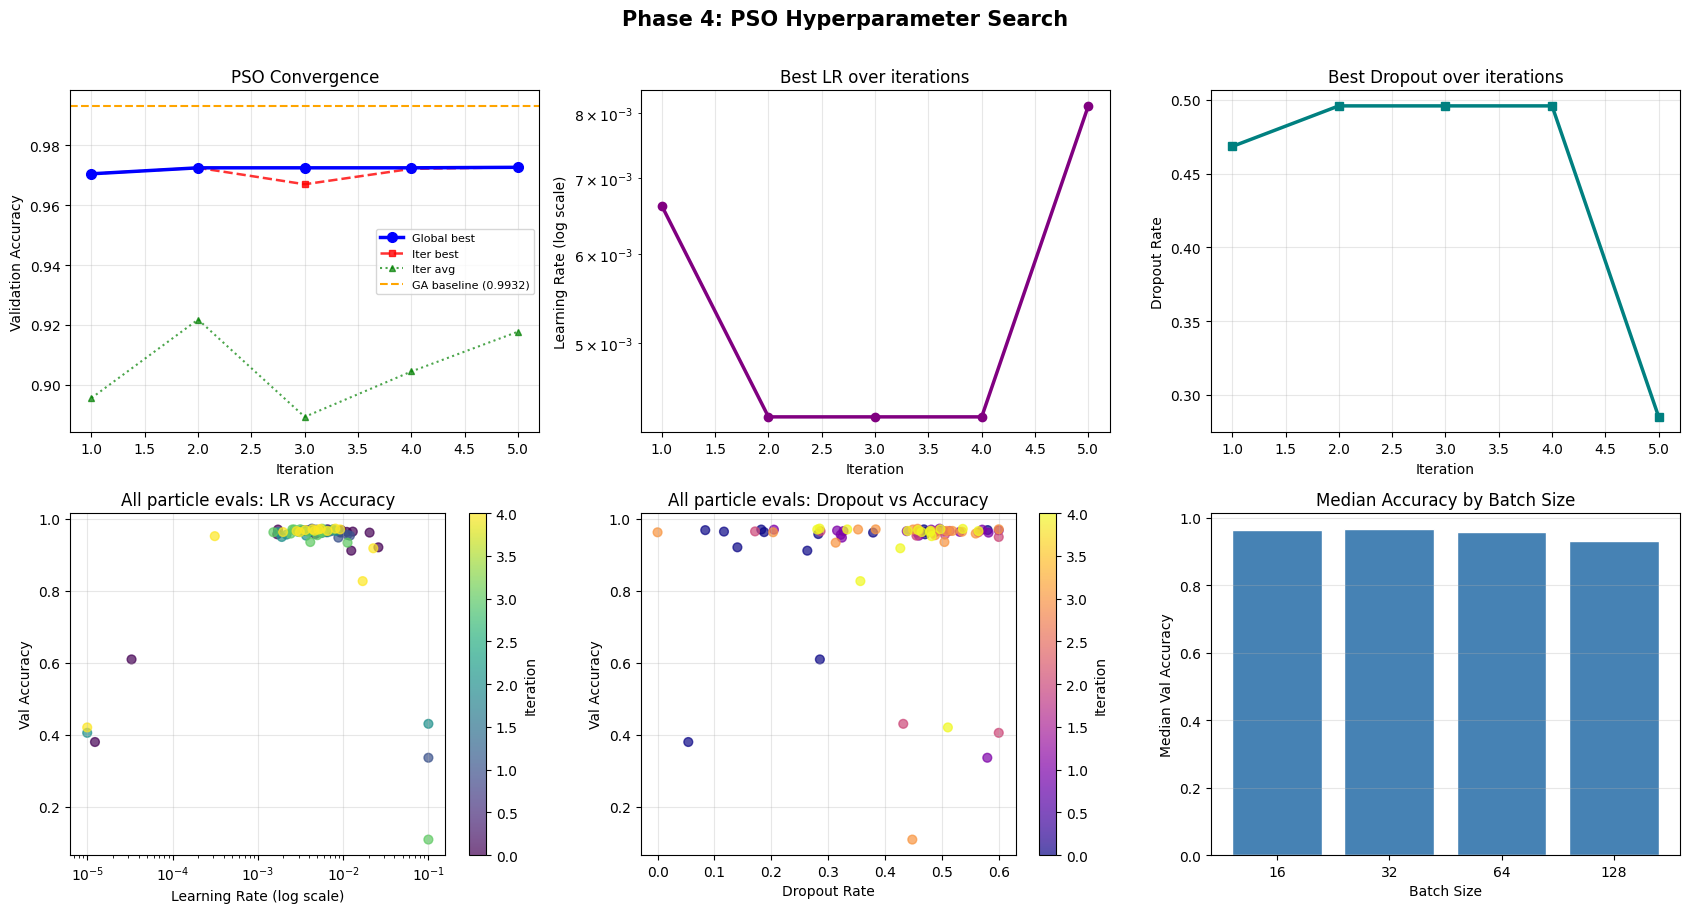

Plot saved → /content/nas_project/results/plots/pso_convergence.png


In [13]:
history  = pso_result['history']
all_eval = pso_result['all_evals']

iters     = [h['iteration'] + 1    for h in history]
gbest     = [h['gbest_fitness']    for h in history]
iter_best = [h['iter_best']        for h in history]
iter_avg  = [h['iter_avg']         for h in history]
best_lr   = [h['best_lr']          for h in history]
best_drop = [h['best_dropout']     for h in history]
best_bs   = [h['best_batch']       for h in history]

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
fig.suptitle('Phase 4: PSO Hyperparameter Search', fontsize=15, fontweight='bold', y=1.01)

# ── 1. Global best convergence ───────────────────────────────────────
ax = axes[0][0]
ax.plot(iters, gbest,     'b-o', lw=2.5, ms=7,  label='Global best', zorder=3)
ax.plot(iters, iter_best, 'r--s', lw=1.8, ms=5, label='Iter best',   alpha=0.8)
ax.plot(iters, iter_avg,  'g:^',  lw=1.5, ms=4, label='Iter avg',    alpha=0.7)
ax.axhline(y=BEST_GA_ACC, color='orange', lw=1.5, ls='--', label=f'GA baseline ({BEST_GA_ACC:.4f})')
ax.set_xlabel('Iteration');  ax.set_ylabel('Validation Accuracy')
ax.set_title('PSO Convergence');  ax.legend(fontsize=8);  ax.grid(True, alpha=0.3)

# ── 2. Learning rate convergence ─────────────────────────────────────
ax = axes[0][1]
ax.semilogy(iters, best_lr, 'purple', lw=2.5, marker='o', ms=6)
ax.set_xlabel('Iteration');  ax.set_ylabel('Learning Rate (log scale)')
ax.set_title('Best LR over iterations');  ax.grid(True, alpha=0.3)

# ── 3. Dropout convergence ────────────────────────────────────────────
ax = axes[0][2]
ax.plot(iters, best_drop, 'teal', lw=2.5, marker='s', ms=6)
ax.set_xlabel('Iteration');  ax.set_ylabel('Dropout Rate')
ax.set_title('Best Dropout over iterations');  ax.grid(True, alpha=0.3)

# ── 4. Scatter: all particle evaluations (lr vs val_acc) ─────────────
ax = axes[1][0]
lrs  = [e['lr']       for e in all_eval]
accs = [e['fitness']  for e in all_eval]
its  = [e['iteration'] for e in all_eval]
sc = ax.scatter(lrs, accs, c=its, cmap='viridis', alpha=0.7, s=40)
plt.colorbar(sc, ax=ax, label='Iteration')
ax.set_xscale('log')
ax.set_xlabel('Learning Rate (log scale)');  ax.set_ylabel('Val Accuracy')
ax.set_title('All particle evals: LR vs Accuracy');  ax.grid(True, alpha=0.3)

# ── 5. Scatter: dropout vs val_acc ────────────────────────────────────
ax = axes[1][1]
drops = [e['dropout'] for e in all_eval]
sc2   = ax.scatter(drops, accs, c=its, cmap='plasma', alpha=0.7, s=40)
plt.colorbar(sc2, ax=ax, label='Iteration')
ax.set_xlabel('Dropout Rate');  ax.set_ylabel('Val Accuracy')
ax.set_title('All particle evals: Dropout vs Accuracy');  ax.grid(True, alpha=0.3)

# ── 6. Batch size distribution ───────────────────────────────────────
ax = axes[1][2]
bss    = [e['batch_size'] for e in all_eval]
bs_acc = {}
for b, a in zip(bss, accs):
    bs_acc.setdefault(b, []).append(a)
bs_vals   = sorted(bs_acc.keys())
bs_medians = [np.median(bs_acc[b]) for b in bs_vals]
ax.bar([str(b) for b in bs_vals], bs_medians, color='steelblue', edgecolor='white')
ax.set_xlabel('Batch Size');  ax.set_ylabel('Median Val Accuracy')
ax.set_title('Median Accuracy by Batch Size');  ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
save_path = f'{PROJECT_ROOT}/results/plots/pso_convergence.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot saved → {save_path}')

---
## STEP 7: Compare PSO-Tuned vs Default Hyperparameters
The key paper result — how much does PSO improve over the default Adam settings?

In [14]:
from training.proxy_trainer import proxy_train
from search_space.chromosome import decode_chromosome

# ── Fixed val loader ─────────────────────────────────────────────────
_, val_loader_fixed, _ = get_dataloaders(batch_size=64)

# ── Best PSO hyperparameters ──────────────────────────────────────────
best_hp = pso_result['best_hyperparams']

# ── Default hyperparameters ───────────────────────────────────────────
default_hp = {'lr': 1e-3, 'dropout': 0.3, 'batch_size': 64}

print('Running comparison (5 epochs each)...')
print('='*55)

# Default
print('\n[1/2] Default hyperparameters...')
default_train_loader, _, _ = get_dataloaders(batch_size=default_hp['batch_size'])
model_default = decode_chromosome(BEST_CHROMOSOME)
result_default = proxy_train(
    model_default, default_train_loader, val_loader_fixed,
    DEVICE, epochs=5, lr=default_hp['lr'], verbose=True
)

# PSO-tuned
print(f'\n[2/2] PSO-tuned hyperparameters (lr={best_hp["lr"]:.2e}, '
      f'dropout={best_hp["dropout"]:.3f}, bs={best_hp["batch_size"]})...')
pso_train_loader, _, _ = get_dataloaders(batch_size=best_hp['batch_size'])
model_pso = decode_chromosome(BEST_CHROMOSOME)
result_pso = proxy_train(
    model_pso, pso_train_loader, val_loader_fixed,
    DEVICE, epochs=5, lr=best_hp['lr'], verbose=True
)

print('\n' + '='*55)
print('  COMPARISON SUMMARY')
print('='*55)
print(f'  Default  → val_acc = {result_default["val_accuracy"]:.4f} '
      f'({result_default["val_accuracy"]*100:.2f}%)')
print(f'  PSO-tuned → val_acc = {result_pso["val_accuracy"]:.4f} '
      f'({result_pso["val_accuracy"]*100:.2f}%)')
gain = (result_pso['val_accuracy'] - result_default['val_accuracy']) * 100
print(f'  Improvement       : {gain:+.2f}%')
print('='*55)

Running comparison (5 epochs each)...

[1/2] Default hyperparameters...
  Epoch 1/5 loss=0.9311 val=0.8348
  Epoch 2/5 loss=0.3733 val=0.9213
  Epoch 3/5 loss=0.2350 val=0.8575
  Epoch 4/5 loss=0.1696 val=0.9565
  Epoch 5/5 loss=0.1306 val=0.9640

[2/2] PSO-tuned hyperparameters (lr=8.12e-03, dropout=0.285, bs=32)...
  Epoch 1/5 loss=1.0360 val=0.8588
  Epoch 2/5 loss=0.4415 val=0.9348
  Epoch 3/5 loss=0.2932 val=0.9583
  Epoch 4/5 loss=0.2075 val=0.9572
  Epoch 5/5 loss=0.1541 val=0.9750

  COMPARISON SUMMARY
  Default  → val_acc = 0.9640 (96.40%)
  PSO-tuned → val_acc = 0.9750 (97.50%)
  Improvement       : +1.10%


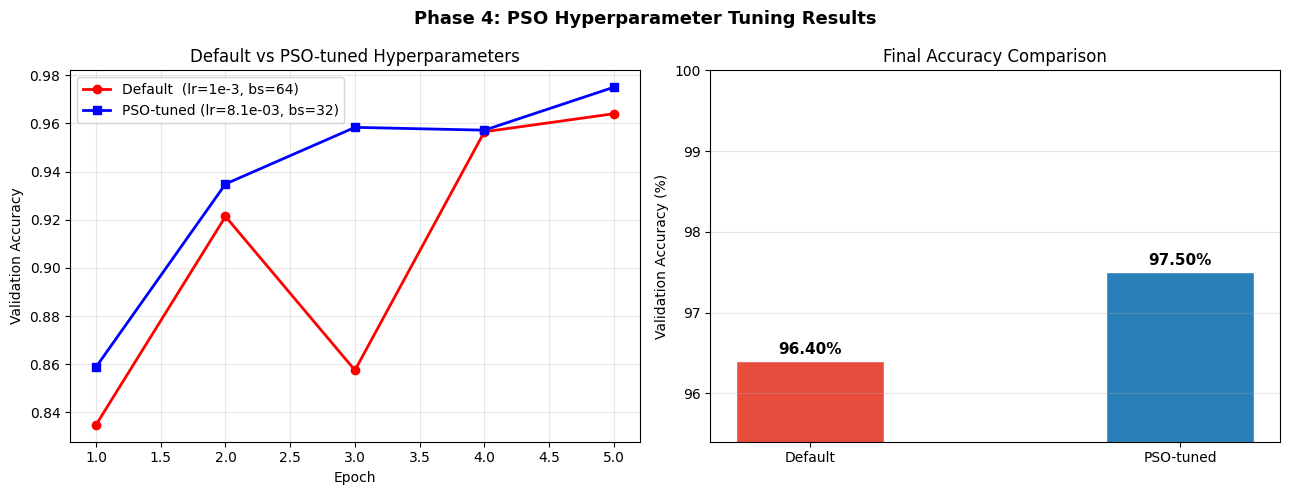

 Comparison plot saved → /content/nas_project/results/plots/pso_comparison.png


In [15]:
# ── Comparison plot ────────────────────────────────────────────────────
epochs_x = list(range(1, 6))
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Val accuracy curves
ax = axes[0]
ax.plot(epochs_x, result_default['val_accs'], 'r-o', lw=2, ms=6,
        label=f'Default  (lr=1e-3, bs=64)')
ax.plot(epochs_x, result_pso['val_accs'],     'b-s', lw=2, ms=6,
        label=f'PSO-tuned (lr={best_hp["lr"]:.1e}, bs={best_hp["batch_size"]})')
ax.set_xlabel('Epoch');  ax.set_ylabel('Validation Accuracy')
ax.set_title('Default vs PSO-tuned Hyperparameters');  ax.legend()
ax.grid(True, alpha=0.3)

# Bar chart: final accuracy
ax2 = axes[1]
labels = ['Default', 'PSO-tuned']
vals   = [result_default['val_accuracy'], result_pso['val_accuracy']]
colors = ['#e74c3c', '#2980b9']
bars   = ax2.bar(labels, [v*100 for v in vals], color=colors, width=0.4, edgecolor='white')
for bar, v in zip(bars, vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{v*100:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax2.set_ylabel('Validation Accuracy (%)');  ax2.set_ylim([min(vals)*100 - 1, 100])
ax2.set_title('Final Accuracy Comparison');  ax2.grid(True, alpha=0.3, axis='y')

plt.suptitle('Phase 4: PSO Hyperparameter Tuning Results', fontsize=13, fontweight='bold')
plt.tight_layout()
save_path = f'{PROJECT_ROOT}/results/plots/pso_comparison.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f' Comparison plot saved → {save_path}')

---
## STEP 8: Save Best Hyperparameters for Phase 5+6

In [16]:
# Save best hyperparams as a standalone JSON — Phase 6 will use these
best_config = {
    'chromosome'   : BEST_CHROMOSOME,
    'ga_val_acc'   : BEST_GA_ACC,
    'pso_val_acc'  : pso_result['best_fitness'],
    'hyperparams'  : pso_result['best_hyperparams'],
    'default_val_acc' : result_default['val_accuracy'],
    'improvement_pct' : gain,
}

best_cfg_path = f'{PROJECT_ROOT}/results/logs/best_config.json'
with open(best_cfg_path, 'w') as f:
    json.dump(best_config, f, indent=2)

print('Best config saved:')
print(json.dumps(best_config, indent=2))

Best config saved:
{
  "chromosome": [
    2,
    1,
    3,
    0,
    0,
    0,
    0,
    2,
    2,
    0,
    1,
    0
  ],
  "ga_val_acc": 0.9932,
  "pso_val_acc": 0.9726666666666667,
  "hyperparams": {
    "lr": 0.008116844290450604,
    "dropout": 0.28499208826198885,
    "batch_size": 32
  },
  "default_val_acc": 0.964,
  "improvement_pct": 1.100000000000001
}


---
## STEP 9: Phase 4 Sanity Check

In [17]:
print('=' * 60)
print('  PHASE 4 — FINAL SANITY CHECK')
print('=' * 60)

checks = []

# Files
files = [
    'pso/pso_optimizer.py',
    'pso/pso_fitness.py',
    'results/logs/pso_results.json',
    'results/logs/best_config.json',
    'results/plots/pso_convergence.png',
    'results/plots/pso_comparison.png',
]
print('\n📄 Files:')
for f in files:
    path = f'{PROJECT_ROOT}/{f}'
    ok   = os.path.isfile(path)
    size = os.path.getsize(path) if ok else 0
    print(f'   {"✅" if ok else "❌"}  {f}  ({size:,} bytes)')
    checks.append(ok)

# PSO results
print('\n📊 PSO Results:')
n_evals    = len(pso_result['all_evals'])
best_fit   = pso_result['best_fitness']
best_hp    = pso_result['best_hyperparams']
ok1 = n_evals > 0
ok2 = best_fit > BEST_GA_ACC - 0.05  # within 5% of GA baseline
ok3 = 1e-5 <= best_hp['lr'] <= 0.1
ok4 = 0.0  <= best_hp['dropout'] <= 0.6
ok5 = best_hp['batch_size'] in [16, 32, 64, 128]
print(f'   {"✅" if ok1 else "❌"}  Total evaluations      : {n_evals}')
print(f'   {"✅" if ok2 else "⚠️ "} Best PSO fitness       : {best_fit:.4f}')
print(f'   {"✅" if ok3 else "❌"}  Best lr in valid range : {best_hp["lr"]:.2e}')
print(f'   {"✅" if ok4 else "❌"}  Best dropout valid     : {best_hp["dropout"]:.3f}')
print(f'   {"✅" if ok5 else "❌"}  Best batch_size valid  : {best_hp["batch_size"]}')
checks += [ok1, ok2, ok3, ok4, ok5]

# Comparison
print('\n📈 Comparison:')
print(f'   GA proxy baseline : {BEST_GA_ACC:.4f}')
print(f'   Default HP result : {result_default["val_accuracy"]:.4f}')
print(f'   PSO-tuned result  : {result_pso["val_accuracy"]:.4f}')
print(f'   Improvement       : {gain:+.2f}%')

print()
print('=' * 60)
if all(checks):
    print('  🎉  PHASE 4 COMPLETE — Ready for Phase 5 (Surrogate Model)')
else:
    print(f'  ⚠️   {sum(checks)}/{len(checks)} checks passed')
print('=' * 60)

  PHASE 4 — FINAL SANITY CHECK

📄 Files:
   ✅  pso/pso_optimizer.py  (6,307 bytes)
   ✅  pso/pso_fitness.py  (2,435 bytes)
   ✅  results/logs/pso_results.json  (23,657 bytes)
   ✅  results/logs/best_config.json  (350 bytes)
   ✅  results/plots/pso_convergence.png  (247,741 bytes)
   ✅  results/plots/pso_comparison.png  (113,228 bytes)

📊 PSO Results:
   ✅  Total evaluations      : 75
   ✅ Best PSO fitness       : 0.9727
   ✅  Best lr in valid range : 8.12e-03
   ✅  Best dropout valid     : 0.285
   ✅  Best batch_size valid  : 32

📈 Comparison:
   GA proxy baseline : 0.9932
   Default HP result : 0.9640
   PSO-tuned result  : 0.9750
   Improvement       : +1.10%

  🎉  PHASE 4 COMPLETE — Ready for Phase 5 (Surrogate Model)


---
## STEP 10: Save to Google Drive

In [18]:
from google.colab import drive
import shutil
drive.mount('/content/drive')
DRIVE_PATH = '/content/drive/MyDrive/nas_project'
if os.path.exists(DRIVE_PATH): shutil.rmtree(DRIVE_PATH)
shutil.copytree(PROJECT_ROOT, DRIVE_PATH)
print(f'✅ Saved to Google Drive: {DRIVE_PATH}')

ValueError: mount failed

---
## Phase 4 Summary

| Component | File | Status |
|-----------|------|--------|
| PSO engine (pure NumPy) | `pso/pso_optimizer.py` | ✅ |
| PSO fitness function | `pso/pso_fitness.py` | ✅ |
| PSO convergence plots | `results/plots/pso_convergence.png` | ✅ |
| Default vs PSO comparison | `results/plots/pso_comparison.png` | ✅ |
| Full PSO trace (all evals) | `results/logs/pso_results.json` | ✅ |
| Best config for Phase 6 | `results/logs/best_config.json` | ✅ |

---
### Key design decisions:
- **Pure NumPy PSO** — no library dependency, fully transparent for the paper
- **Inertia decay** (`w × 0.99` per iter) — broad exploration early, fine exploitation late
- **Velocity reflection** on bound violation — particles bounce back rather than getting stuck at edges
- **`PSOFitnessEvaluator`** rebuilds the DataLoader per call when batch_size changes — correct behaviour, avoids stale loader bugs
- **`best_config.json`** stores chromosome + best HP together — Phase 6 loads this for the full 20-epoch multi-objective evaluation

---
### ▶️ Next: Phase 5 — Surrogate Fitness Model
We will:
- Train XGBoost regressor on `(50 chromosomes → val_accuracy)` from Phase 3
- Validate with R² score and predicted-vs-actual scatter plot
- Integrate surrogate into the GA loop (only train top-K predicted architectures)
- Measure compute savings: evals with surrogate vs without
- This is the **key novelty** section for the paper

In [19]:
import shutil
from google.colab import files

# Define the name of the zip file
zip_filename = 'nas_project_complete.zip'

# Create a zip archive of the nas_project folder
# base_name: name of the zip file to create
# format: zip
# root_dir: the directory to zip
shutil.make_archive(zip_filename.replace('.zip', ''), 'zip', PROJECT_ROOT)

print(f'✅ Archive created: {zip_filename}')

# Trigger download to local machine
files.download(zip_filename)

✅ Archive created: nas_project_complete.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>